# Класификация на газове чрез данни от IoT сензорна мрежа

Този notebook е демонстрационен проект по дисциплината „Анализ на големи масиви данни и откриване на знания“, 

реализиран от: **Димитър Николов, ф.н. 471222022**.

Темата на презентацията е **„Безжични сензорни мрежи за IoT“**, а проектът демонстрира как данни от сензорна система могат да бъдат използвани за обучение на ML модел.

Задачата е **таблична класификация**: по измервания от химически сензори моделът трябва да предскаже кой газ е бил засечен.

## 1. Инсталиране на библиотеки

`pip install -r requirements.txt`

## 2. Импортиране на нужните библиотеки

In [1]:
from pathlib import Path
import zipfile
import urllib.request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fastai.tabular.all import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Папка, в която ще запазваме резултатите
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

## 3. Зареждане на dataset-а

Използваме **Gas Sensor Array Drift Dataset** от UCI Machine Learning Repository.

Важно: пакетът `ucimlrepo` понякога връща грешка за този dataset, защото UCI не го предоставя като стандартизиран CSV import. Затова тук го сваляме директно като `.zip` файл от UCI и парсваме `.dat` файловете.

Форматът на редовете е подобен на LIBSVM:

```text
1 1:15596.162100 2:1.868245 ... 128:-2.654529
```

Първото число е класът на газа, а следващите стойности са `feature:value`.

In [3]:
ZIP_PATH = DATA_DIR / "gas_sensor_array_drift_dataset.zip"

DATASET_URLS = [
    "https://archive.ics.uci.edu/static/public/224/gas+sensor+array+drift+dataset.zip",
    "https://archive.ics.uci.edu/static/public/224/gas%2Bsensor%2Barray%2Bdrift%2Bdataset.zip",
]

GAS_LABELS = {
    1: "Ethanol",
    2: "Ethylene",
    3: "Ammonia",
    4: "Acetaldehyde",
    5: "Acetone",
    6: "Toluene",
}


def download_dataset_if_needed() -> None:
    """Сваля dataset-а само ако още не съществува локално."""
    if ZIP_PATH.exists():
        print(f"Dataset already exists: {ZIP_PATH}")
        return

    last_error = None

    for url in DATASET_URLS:
        try:
            print(f"Downloading dataset from: {url}")
            urllib.request.urlretrieve(url, ZIP_PATH)
            print(f"Saved to: {ZIP_PATH}")
            return
        except Exception as error:
            last_error = error
            print("Download failed for this URL. Trying next one...")

    raise RuntimeError(
        "Dataset download failed. Open the UCI page manually, download the ZIP file, "
        f"and place it here: {ZIP_PATH}"
    ) from last_error


def parse_libsvm_line(line: str, batch_name: str) -> dict:
    """Парсва един ред от .dat файл във формат: class feature:value feature:value ..."""
    parts = line.strip().split()

    target_id = int(parts[0])
    row = {
        "target_id": target_id,
        "target": GAS_LABELS[target_id],
        "batch": batch_name,
    }

    for item in parts[1:]:
        feature_id, value = item.split(":")
        row[f"feature_{int(feature_id):03d}"] = float(value)

    return row


def load_gas_sensor_dataset() -> pd.DataFrame:
    """Сваля ZIP архива, чете batch*.dat файловете и връща pandas DataFrame."""
    download_dataset_if_needed()

    rows = []

    with zipfile.ZipFile(ZIP_PATH, "r") as archive:
        batch_files = [
            name for name in archive.namelist()
            if name.lower().endswith(".dat") and "batch" in Path(name).name.lower()
        ]

        batch_files = sorted(
            batch_files,
            key=lambda name: int("".join(ch for ch in Path(name).stem if ch.isdigit()))
        )

        print("Found batch files:")
        for file_name in batch_files:
            print(" -", file_name)

        for file_name in batch_files:
            batch_name = Path(file_name).stem

            with archive.open(file_name) as file:
                for raw_line in file:
                    line = raw_line.decode("utf-8").strip()

                    if line:
                        rows.append(parse_libsvm_line(line, batch_name))

    df = pd.DataFrame(rows)

    feature_columns = sorted([column for column in df.columns if column.startswith("feature_")])
    df = df[["target_id", "target", "batch"] + feature_columns]

    return df


df = load_gas_sensor_dataset()

print("Dataset shape:", df.shape)
df.head()

Dataset already exists: ../data/raw/gas_sensor_array_drift_dataset.zip
Found batch files:
 - Dataset/batch1.dat
 - Dataset/batch2.dat
 - Dataset/batch3.dat
 - Dataset/batch4.dat
 - Dataset/batch5.dat
 - Dataset/batch6.dat
 - Dataset/batch7.dat
 - Dataset/batch8.dat
 - Dataset/batch9.dat
 - Dataset/batch10.dat
Dataset shape: (13910, 131)


,target_id,target,batch,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128
0,1,Ethanol,batch1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,1,Ethanol,batch1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,...,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,1,Ethanol,batch1,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,...,-2.384784,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370
3,1,Ethanol,batch1,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957
4,1,Ethanol,batch1,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


In [4]:
# Първите 5 реда от dataset-а
df.head()

,target_id,target,batch,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128
0,1,Ethanol,batch1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,1,Ethanol,batch1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,...,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,1,Ethanol,batch1,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,...,-2.384784,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370
3,1,Ethanol,batch1,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957
4,1,Ethanol,batch1,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


In [5]:
# Класове газове в dataset-а
df[["target_id", "target"]].drop_duplicates().sort_values("target_id")

,target_id,target
0,1,Ethanol
84,2,Ethylene
172,3,Ammonia
271,4,Acetaldehyde
301,5,Acetone
371,6,Toluene


## 4. Подготовка на данните

Колоните са:

- `target_id` - числов ID на класа;
- `target` - името на газа, което моделът ще предсказва;
- `batch` - batch/времева група от dataset-а;
- `feature_001` до `feature_128` - числови характеристики от сензорите.

За обучението използваме само `feature_001` до `feature_128` като входни данни. Не използваме `batch` като вход, за да не помагаме изкуствено на модела чрез времевата група.

In [6]:
feature_columns = [column for column in df.columns if column.startswith("feature_")]

print("Брой features:", len(feature_columns))
print("Dataset shape:", df.shape)

df[["target", "batch"] + feature_columns[:5]].head()

Брой features: 128
Dataset shape: (13910, 131)


,target,batch,feature_001,feature_002,feature_003,feature_004,feature_005
0,Ethanol,batch1,15596.1621,1.868245,2.371604,2.803678,7.512213
1,Ethanol,batch1,26402.0704,2.532401,5.411209,6.509906,7.658469
2,Ethanol,batch1,42103.5820,3.454189,8.198175,10.508439,11.611003
3,Ethanol,batch1,42825.9883,3.451192,12.113940,16.266853,39.910056
4,Ethanol,batch1,58151.1757,4.194839,11.455096,15.715298,17.654915


In [7]:
# Проверка за липсващи стойности
missing_values = df.isna().sum().sum()
print("Общ брой липсващи стойности:", missing_values)

Общ брой липсващи стойности: 0


In [8]:
# Проверяваме разпределението на класовете
class_counts = df["target"].value_counts().sort_index()
class_counts

target
Acetaldehyde    1936
Acetone         3009
Ammonia         1641
Ethanol         2565
Ethylene        2926
Toluene         1833
Name: count, dtype: int64

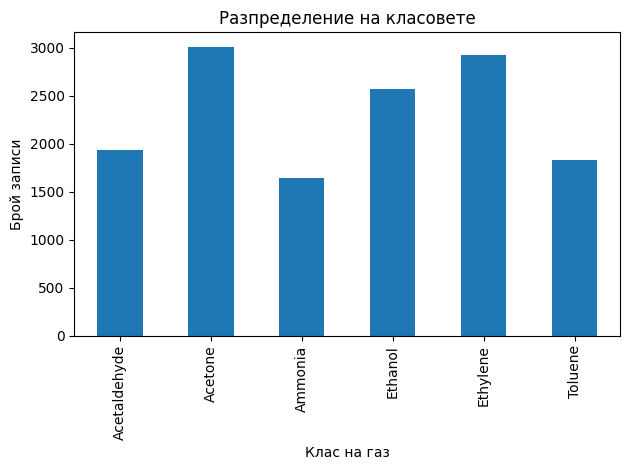

In [9]:
# Визуализация на разпределението на класовете
class_counts.plot(kind="bar")
plt.title("Разпределение на класовете")
plt.xlabel("Клас на газ")
plt.ylabel("Брой записи")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "class_distribution.png")
plt.show()

## 5. Train/validation разделяне

Разделяме данните на:

- training set - използва се за обучение
- validation set - използва се за оценка по време на обучението

Използваме `stratify`, за да запазим подобно разпределение на класовете в двете части.

In [10]:
train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["target"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

Train shape: (11128, 131)
Validation shape: (2782, 131)


## 6. Baseline модел: Random Forest

Първо обучаваме класически ML модел - **Random Forest Classifier**.

Той служи като baseline, с който можем да сравним FastAI модела.

In [11]:
X_train = train_df[feature_columns]
y_train = train_df["target"]

X_valid = valid_df[feature_columns]
y_valid = valid_df["target"]

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_valid)

rf_accuracy = accuracy_score(y_valid, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.9942


In [12]:
rf_report = classification_report(y_valid, rf_predictions)
print(rf_report)

with open(RESULTS_DIR / "random_forest_results.txt", "w", encoding="utf-8") as file:
    file.write(f"Random Forest Accuracy: {rf_accuracy:.4f}\n\n")
    file.write(rf_report)

              precision    recall  f1-score   support

Acetaldehyde       0.99      0.99      0.99       387
     Acetone       0.99      1.00      0.99       602
     Ammonia       1.00      0.98      0.99       328
     Ethanol       1.00      1.00      1.00       513
    Ethylene       1.00      0.99      1.00       585
     Toluene       0.99      1.00      0.99       367

    accuracy                           0.99      2782
   macro avg       0.99      0.99      0.99      2782
weighted avg       0.99      0.99      0.99      2782



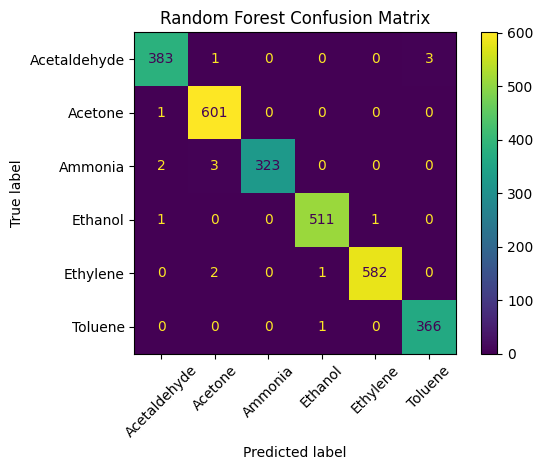

In [13]:
ConfusionMatrixDisplay.from_predictions(y_valid, rf_predictions)
plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_forest_confusion_matrix.png")
plt.show()

## 7. FastAI Tabular Learner

Сега обучаваме основния модел чрез **FastAI Tabular Learner**.

Тъй като всички входни характеристики са числови, ги подаваме като `cont_names`. Нямаме категорийни входни колони, затова `cat_names` е празен списък.

In [14]:
# Обединяваме train и validation обратно, защото FastAI очаква един DataFrame + индекси за validation set.
combined_df = pd.concat([train_df, valid_df]).reset_index(drop=True)

valid_idx = list(range(len(train_df), len(combined_df)))

cont_names = [column for column in combined_df.columns if column != "target"]
cat_names = []
dep_var = "target"

print("Брой числови характеристики:", len(cont_names))
print("Target:", dep_var)

Брой числови характеристики: 130
Target: target


In [15]:
# Използваме само feature колоните като вход (без string колоната 'batch' и без target_id)
cont_names = feature_columns
cat_names = []

dls = TabularDataLoaders.from_df(
    combined_df,
    y_names=dep_var,
    valid_idx=valid_idx,
    cat_names=cat_names,
    cont_names=cont_names,
    procs=[Normalize],
    y_block=CategoryBlock,
    bs=64
)

dls.show_batch(max_n=5)

/Users/dimitar/Documents/University/ИС/iot-gas-sensor-classification/.venv/lib/python3.14/site-packages/fastai/torch_core.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  else as_tensor(x.values, **kwargs) if isinstance(x, (pd.Series, pd.DataFrame))


,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,feature_010,feature_011,feature_012,feature_013,feature_014,feature_015,feature_016,feature_017,feature_018,feature_019,feature_020,feature_021,feature_022,feature_023,feature_024,feature_025,feature_026,feature_027,feature_028,feature_029,feature_030,feature_031,feature_032,feature_033,feature_034,feature_035,feature_036,feature_037,feature_038,feature_039,feature_040,feature_041,feature_042,feature_043,feature_044,feature_045,feature_046,feature_047,feature_048,feature_049,feature_050,feature_051,feature_052,feature_053,feature_054,feature_055,feature_056,feature_057,feature_058,feature_059,feature_060,feature_061,feature_062,feature_063,feature_064,feature_065,feature_066,feature_067,feature_068,feature_069,feature_070,feature_071,feature_072,feature_073,feature_074,feature_075,feature_076,feature_077,feature_078,feature_079,feature_080,feature_081,feature_082,feature_083,feature_084,feature_085,feature_086,feature_087,feature_088,feature_089,feature_090,feature_091,feature_092,feature_093,feature_094,feature_095,feature_096,feature_097,feature_098,feature_099,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,target
0,4535.574219,1.209080,1.008280,1.408911,2.653614,-0.893963,-1.199742,-2.281013,4002.042969,1.191094,0.870192,1.273468,2.597862,-0.810891,-1.101737,-2.202110,8480.528320,6.109455,1.673460,2.197646,2.504807,-1.504893,-2.049241,-2.901568,7990.980469,5.897883,1.539561,2.005314,2.580297,-1.428710,-2.004902,-2.516321,1253.778320,2.131674,0.317021,0.479617,0.839975,-0.284796,-0.460970,-0.840002,1457.145996,2.224458,0.371159,0.556631,0.908405,-0.335389,-0.541002,-0.951982,7738.660156,7.647130,1.747129,2.371067,2.876514,-1.652409,-2.496263,-3.018721,7884.045898,7.820703,1.760316,2.402039,2.831976,-1.718904,-2.657376,-3.368622,4157.753906,1.243303,0.863519,1.110385,2.023172,-0.818151,-1.075832,-2.232159,3331.675781,1.171662,0.715966,0.960918,2.520615,-0.626981,-0.937869,-1.830482,9566.184570,6.317361,1.895405,2.466663,3.002459,-1.690323,-2.327392,-2.801026,5945.336914,6.080182,1.231204,1.634712,1.998029,-1.140657,-1.604045,-2.291746,1437.093750,2.209679,0.369055,0.565888,1.132097,-0.330243,-0.603174,-1.357788,1691.666260,2.323094,0.428452,0.631756,1.005193,-0.377728,-0.602385,-0.987590,8651.843750,8.661753,1.943009,2.631075,3.163151,-1.884475,-2.950022,-3.487155,7229.035156,8.231106,1.648871,2.269562,2.583456,-1.560025,-2.422975,-2.886942,Ethylene
1,32377.201172,2.187075,10.642049,47.615143,73.559853,-7.854316,-23.267370,-48.335361,27715.808594,2.069571,7.573164,12.168621,30.459812,-6.954921,-10.827715,-38.650063,11099.285156,2.654656,3.320643,5.473761,11.768244,-2.838249,-4.872007,-14.613183,11235.882812,2.597256,3.293697,5.419753,10.631316,-2.798742,-4.755933,-14.498039,2141.418701,1.864379,0.819381,2.147665,5.262066,-0.615147,-1.307847,-4.996405,1887.857910,1.774826,0.732980,1.917523,4.404375,-0.553321,-1.192292,-5.399017,13797.491211,2.675971,4.730144,8.692649,13.999118,-3.857657,-6.886324,-16.219196,14606.700195,2.661388,5.079020,9.457024,16.099987,-4.122591,-7.662008,-21.434355,26940.322266,2.227996,6.360666,8.930929,19.737135,-5.370663,-7.738862,-25.384893,19530.345703,2.119492,4.187938,5.741898,12.450878,-3.609540,-5.255879,-17.286297,13309.216797,2.731120,3.737378,5.526410,9.179609,-3.180618,-4.809998,-12.041314,10320.285156,2.649857,2.976576,4.525547,7.395727,-2.539543,-3.874723,-8.318960,3117.839600,1.873319,1.132044,3.022053,5.729265,-0.880790,-1.518318,-4.068478,3137.801758,1.871796,1.131294,2.796166,4.875286,-0.867857,-1.535709,-3.642373,16411.681641,2.818071,5.240906,8.665137,12.484295,-4.352287,-7.072723,-

In [16]:
learn = tabular_learner(
    dls,
    layers=[200, 100],
    metrics=accuracy
)

learn

## 8. Обучение на FastAI модела

Обучаваме модела за 10 епохи.

Ако резултатът е слаб или loss-ът продължава да пада, може да се пробва с повече епохи, например 15 или 20.

In [17]:
learn.fit_one_cycle(10, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.547595,0.342462,0.925234,00:05
1,0.168954,0.195885,0.939612,00:01
2,0.117345,0.117776,0.950395,00:01
3,0.115044,0.170842,0.938174,00:01
4,0.080338,0.070557,0.983106,00:01
5,0.066404,0.062891,0.984903,00:01
6,0.056888,0.098720,0.959022,00:01
7,0.041858,0.061407,0.974479,00:01
8,0.030616,0.030858,0.994249,00:01
9,0.029235,0.058276,0.975557,00:01


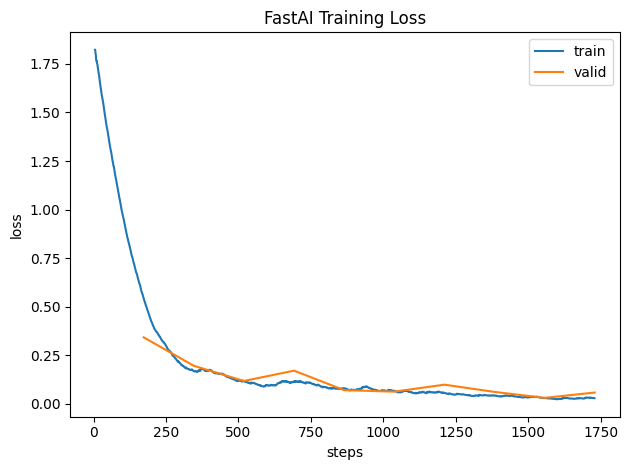

In [18]:
learn.recorder.plot_loss()
plt.title("FastAI Training Loss")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fastai_training_loss.png")
plt.show()

## 9. Оценка на FastAI модела

Изчисляваме accuracy върху validation set и визуализираме confusion matrix.

In [19]:
fastai_results = learn.validate()
fastai_accuracy = fastai_results[1]

print(f"FastAI Validation Accuracy: {fastai_accuracy:.4f}")

FastAI Validation Accuracy: 0.9756


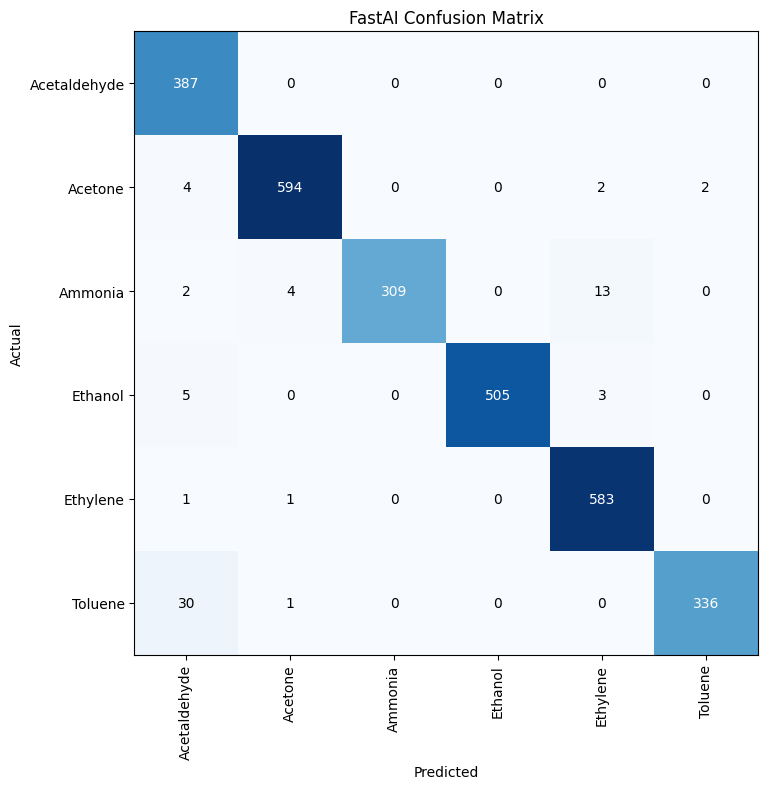

In [20]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(8, 8))
plt.title("FastAI Confusion Matrix")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fastai_confusion_matrix.png")
plt.show()

In [21]:
# Запазваме обучен FastAI модел
learn.export(RESULTS_DIR / "fastai_gas_sensor_model.pkl")
print("Моделът е запазен в results/fastai_gas_sensor_model.pkl")

Моделът е запазен в results/fastai_gas_sensor_model.pkl


## 10. Сравнение на моделите

Тук сравняваме резултатите от Random Forest и FastAI модела.

In [22]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "FastAI Tabular Learner"],
    "Accuracy": [rf_accuracy, float(fastai_accuracy)]
})

comparison

,Model,Accuracy
0,Random Forest,0.994249
1,FastAI Tabular Learner,0.975557


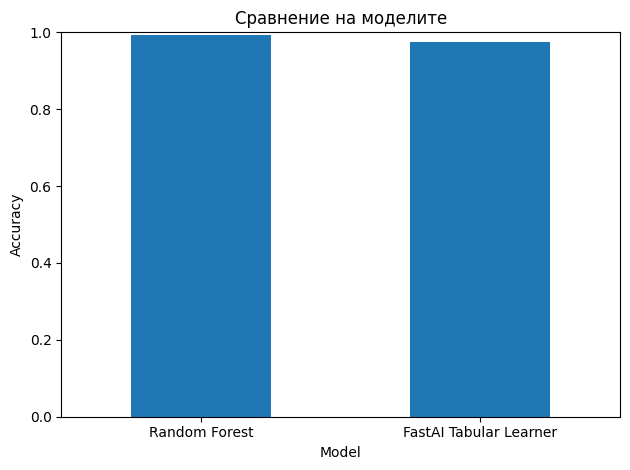

In [23]:
comparison.plot(x="Model", y="Accuracy", kind="bar", legend=False)
plt.title("Сравнение на моделите")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison.png")
plt.show()

## 11. Извод

Проектът демонстрира как данни от IoT сензорна система могат да бъдат използвани за автоматично разпознаване на различни газове.

Този подход има реално приложение при:

- мониторинг на въздуха;
- индустриална безопасност;
- ранно откриване на опасни газове;
- анализ на данни от безжични сензорни мрежи;
- автоматизирано вземане на решения в IoT системи.